# Sesión 9 · Redes neuronales en práctica controlada
### *Cómo operar una red neuronal con rigor técnico*

Este notebook está alineado **bloque a bloque** con el material teórico de la Sesión 9.

- Cada sección **Notebook · Bloque N** corresponde al **BLOQUE N** del documento.
- El objetivo no es “exprimir score”, sino **operar con rigor**: control experimental, baseline, sobreajuste, regularización y estabilidad.


## Notebook · Bloque 0 — Contexto y preparación

En esta sesión vas a:

1. Entrenar modelos simples y una red neuronal pequeña.
2. Comparar contra un baseline.
3. **Ver** el sobreajuste en curvas de pérdida.
4. Analizar métricas y **confianza** (`predict_proba`).
5. Aplicar regularización (L2 / early stopping).
6. Evaluar **estabilidad** (sensibilidad a la semilla).
7. Cerrar con un reto de red minimalista con ruido.

> Regla de oro: **la red neuronal no tiene privilegios**; se justifica solo si aporta valor **de forma estable**.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, log_loss
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Notebook · Bloque 1 — La red mínima (MLP)

En el texto has visto el cálculo básico de una neurona:

\[
y = f\left(\sum_i w_i x_i + b\right)
\]

Aquí no implementamos eso “a mano”. Lo materializamos usando un **perceptrón multicapa (MLP)** con una arquitectura pequeña.

**Objetivo del bloque:** entrenar una red mínima y comprobar el flujo básico `.fit()` → `.predict()` → métricas.


In [2]:
# Dataset base: acotado pero no trivial
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_repeated=0,
    n_classes=2,
    class_sep=1.2,
    flip_y=0.03,
    random_state=RANDOM_STATE
)

# Split: train / temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Split temp -> val / test (15% / 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

X_train.shape, X_val.shape, X_test.shape


((1400, 20), (300, 20), (300, 20))

In [4]:
# MLP mínimo (capacidad deliberadamente pequeña)
mlp_min = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(8,),   # 1 capa oculta, 8 neuronas
        activation="relu",
        solver="adam",
        alpha=0.0001,
        max_iter=400,
        random_state=RANDOM_STATE
    ))
])

mlp_min.fit(X_train, y_train)
y_pred = mlp_min.predict(X_test)

accuracy_score(y_test, y_pred)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9233333333333333

## Notebook · Bloque 2 — La herramienta como “un modelo más”

Comparamos el flujo de trabajo entre:
- **Regresión logística** (modelo clásico)
- **MLP** (red neuronal)

**Objetivo del bloque:** ver que comparten la misma API mental y se comparan bajo las mismas reglas.


In [5]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

logreg.fit(X_train, y_train)

pred_lr = logreg.predict(X_test)
pred_mlp = mlp_min.predict(X_test)

pd.DataFrame([
    {"modelo": "LogisticRegression", "accuracy": accuracy_score(y_test, pred_lr)},
    {"modelo": "MLP (8 neuronas)", "accuracy": accuracy_score(y_test, pred_mlp)},
])


,modelo,accuracy
0,LogisticRegression,0.756667
1,MLP (8 neuronas),0.923333


## Notebook · Bloque 3 — Control del experimento (Train / Validation / Test)

En redes neuronales, **decidir** usando el test destruye el experimento.

- **Train**: aprende pesos
- **Validation**: decide hiperparámetros (capacidad, regularización, parada)
- **Test**: evaluación final (una sola vez)

**Objetivo del bloque:** practicar este protocolo y usarlo más adelante en curvas de pérdida y regularización.


In [6]:
print("Proporciones:")
print(f"Train: {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X):.0%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X):.0%})")


Proporciones:
Train: 1400 (70%)
Val:   300 (15%)
Test:  300 (15%)


## Notebook · Bloque 4 — Baseline obligatorio

Antes de “creer” en una red neuronal, se compara con un baseline.
Usaremos:
- **DummyClassifier** (estrategia: `most_frequent`)
- **LogisticRegression**
- **MLP mínimo**

**Objetivo del bloque:** construir un marcador de modelos (tabla) y justificar el coste estructural.


In [7]:
def eval_classif(y_true, y_pred, y_proba=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        out["log_loss"] = log_loss(y_true, y_proba)
    return out

# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
proba_dummy = dummy.predict_proba(X_test)

# Logistic regression
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)
proba_lr = logreg.predict_proba(X_test)

# MLP mínimo
mlp_min.fit(X_train, y_train)
pred_mlp = mlp_min.predict(X_test)
proba_mlp = mlp_min.predict_proba(X_test)

scoreboard = pd.DataFrame([
    {"modelo": "Dummy (most_frequent)", **eval_classif(y_test, pred_dummy, proba_dummy)},
    {"modelo": "LogisticRegression", **eval_classif(y_test, pred_lr, proba_lr)},
    {"modelo": "MLP (8 neuronas)", **eval_classif(y_test, pred_mlp, proba_mlp)},
]).sort_values("accuracy", ascending=False)

scoreboard


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


,modelo,accuracy,precision,recall,f1,log_loss
2,MLP (8 neuronas),0.923333,0.943662,0.899329,0.920962,0.213848
1,LogisticRegression,0.756667,0.783582,0.704698,0.742049,0.489400
0,Dummy (most_frequent),0.503333,0.000000,0.000000,0.000000,17.901681


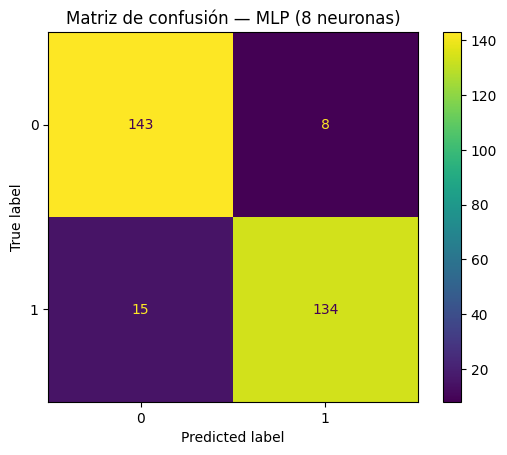

In [8]:
# Matriz de confusión (ejemplo): mejor modelo por accuracy
best_name = scoreboard.iloc[0]["modelo"]

model_preds = {
    "Dummy (most_frequent)": pred_dummy,
    "LogisticRegression": pred_lr,
    "MLP (8 neuronas)": pred_mlp
}
best_pred = model_preds[best_name]

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matriz de confusión — {best_name}")
plt.show()


## Notebook · Bloque 5 — Overfitting visible (curvas de pérdida)

Para trazar **train vs val loss** de forma comparable, simulamos “épocas” usando:
- `warm_start=True`
- `max_iter=1` (una iteración por llamada a `.fit()`)

En cada “época” calculamos:
- `log_loss` en train
- `log_loss` en val

**Objetivo del bloque:** ver el sobreajuste como separación de curvas y entender *dónde* empieza.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

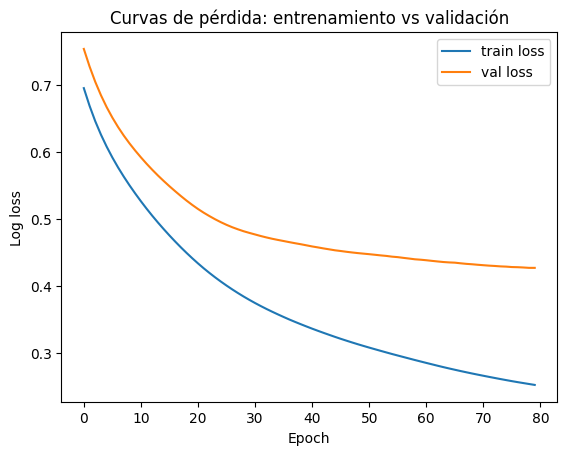

Min val loss: 0.4268 en época 79


In [9]:
def train_loss_curves(
    X_train, y_train, X_val, y_val,
    hidden_layer_sizes=(32,),
    activation="relu",
    alpha=0.0001,
    solver="adam",
    epochs=60,
    random_state=42
):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xva = scaler.transform(X_val)

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,
        max_iter=1,
        warm_start=True,
        random_state=random_state
    )

    train_losses, val_losses = [], []
    for _ in range(epochs):
        mlp.fit(Xtr, y_train)
        train_losses.append(log_loss(y_train, mlp.predict_proba(Xtr)))
        val_losses.append(log_loss(y_val, mlp.predict_proba(Xva)))

    return train_losses, val_losses

train_losses, val_losses = train_loss_curves(
    X_train, y_train, X_val, y_val,
    hidden_layer_sizes=(32,),
    alpha=0.0001,
    epochs=80,
    random_state=RANDOM_STATE
)

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.title("Curvas de pérdida: entrenamiento vs validación")
plt.legend()
plt.show()

print(f"Min val loss: {min(val_losses):.4f} en época {int(np.argmin(val_losses))}")


## Notebook · Bloque 6 — “No solo acertar”: confianza con `predict_proba`

Una red puede acertar con un margen mínimo (p≈0.51) o con alta confianza (p≈0.99).
Ambos cuentan como “acierto”, pero no aportan la misma robustez.

**Objetivo del bloque:** inspeccionar probabilidades y detectar predicciones frágiles.


In [10]:
mlp_min.fit(X_train, y_train)
proba = mlp_min.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

df_proba = pd.DataFrame({
    "y_true": y_test,
    "proba_clase_1": proba,
    "y_pred": pred,
    "acierta": (pred == y_test),
})
df_proba["distancia_al_50%"] = np.abs(df_proba["proba_clase_1"] - 0.5)

# Casos “frágiles”: cerca del umbral 0.5
df_proba.sort_values("distancia_al_50%").head(12)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


,y_true,proba_clase_1,y_pred,acierta,distancia_al_50%
280,1,0.507456,1,True,0.007456
192,1,0.489766,0,False,0.010234
89,1,0.482919,0,False,0.017081
160,1,0.477449,0,False,0.022551
189,1,0.522882,1,True,0.022882
10,0,0.536246,1,False,0.036246
269,0,0.452681,0,True,0.047319
229,0,0.440355,0,True,0.059645
95,1,0.437157,0,False,0.062843
169,0,0.432375,0,True,0.067625


In [11]:
# Casos “con margen”: muy lejos del umbral 0.5
df_proba.sort_values("distancia_al_50%", ascending=False).head(12)


,y_true,proba_clase_1,y_pred,acierta,distancia_al_50%
177,1,0.999999,1,True,0.499999
173,1,0.999988,1,True,0.499988
278,1,0.999985,1,True,0.499985
69,1,0.999985,1,True,0.499985
268,1,0.999953,1,True,0.499953
172,1,0.999939,1,True,0.499939
137,0,0.000065,0,True,0.499935
230,1,0.999934,1,True,0.499934
134,0,0.000091,0,True,0.499909
78,1,0.999898,1,True,0.499898


## Notebook · Bloque 7 — Regularización: el freno de mano (alpha + early stopping)

Mecanismos:
1) **L2 (`alpha`)**: penaliza pesos grandes.
2) **Early stopping**: detiene cuando la validación deja de mejorar.

**Objetivo del bloque:** ver el impacto en métricas y en curvas de pérdida.


In [12]:
def train_eval_mlp(alpha=0.0001, early_stopping=False, hidden=(32,), seed=42):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=hidden,
            activation="relu",
            solver="adam",
            alpha=alpha,
            early_stopping=early_stopping,
            validation_fraction=0.2,
            n_iter_no_change=10,
            max_iter=600,
            random_state=seed
        ))
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    return eval_classif(y_test, pred, proba)

rows = []
for a in [1e-5, 1e-4, 1e-3, 1e-2]:
    rows.append({"config": f"alpha={a}, early_stopping=False", **train_eval_mlp(alpha=a, early_stopping=False, seed=RANDOM_STATE)})
for a in [1e-5, 1e-4, 1e-3, 1e-2]:
    rows.append({"config": f"alpha={a}, early_stopping=True", **train_eval_mlp(alpha=a, early_stopping=True, seed=RANDOM_STATE)})

pd.DataFrame(rows).sort_values("accuracy", ascending=False)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


,config,accuracy,precision,recall,f1,log_loss
2,"alpha=0.001, early_stopping=False",0.916667,0.930556,0.899329,0.914676,0.293592
0,"alpha=1e-05, early_stopping=False",0.910000,0.923611,0.892617,0.907850,0.295789
1,"alpha=0.0001, early_stopping=False",0.906667,0.917241,0.892617,0.904762,0.296925
3,"alpha=0.01, early_stopping=False",0.906667,0.917241,0.892617,0.904762,0.296940
4,"alpha=1e-05, early_stopping=True",0.853333,0.867133,0.832215,0.849315,0.387219
5,"alpha=0.0001, early_stopping=True",0.853333,0.867133,0.832215,0.849315,0.387219
6,"alpha=0.001, early_stopping=True",0.853333,0.867133,0.832215,0.849315,0.387216
7,"alpha=0.01, early_stopping=True",0.853333,0.867133,0.832215,0.849315,0.387258


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

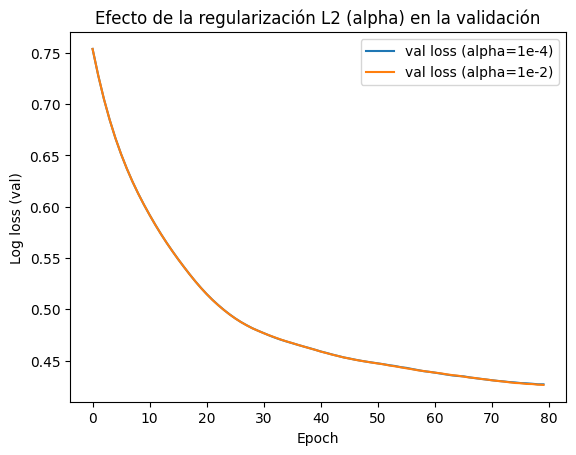

In [13]:
# Curvas de validación para dos valores de alpha (comparativa)
configs = [
    {"label": "alpha=1e-4", "alpha": 1e-4},
    {"label": "alpha=1e-2", "alpha": 1e-2},
]

plt.figure()
for cfg in configs:
    _, va = train_loss_curves(
        X_train, y_train, X_val, y_val,
        hidden_layer_sizes=(32,),
        alpha=cfg["alpha"],
        epochs=80,
        random_state=RANDOM_STATE
    )
    plt.plot(va, label=f"val loss ({cfg['label']})")

plt.xlabel("Epoch")
plt.ylabel("Log loss (val)")
plt.title("Efecto de la regularización L2 (alpha) en la validación")
plt.legend()
plt.show()


## Notebook · Bloque 8 — Estabilidad: sensibilidad a la semilla

Las redes neuronales son estocásticas (inicialización, orden interno, etc.).
Un modelo “bueno una vez” puede ser “malo” con otra semilla.

**Objetivo del bloque:** entrenar varias veces, medir variabilidad y decidir si el modelo es confiable.


In [14]:
def stability_experiment(seeds, alpha=1e-4, hidden=(32,), early_stopping=True):
    rows = []
    for seed in seeds:
        rows.append({"seed": seed, **train_eval_mlp(alpha=alpha, early_stopping=early_stopping, hidden=hidden, seed=seed)})
    return pd.DataFrame(rows)

seeds = list(range(5))
stab = stability_experiment(seeds, alpha=1e-4, hidden=(32,), early_stopping=True)
stab


,seed,accuracy,precision,recall,f1,log_loss
0,0,0.883333,0.901408,0.859060,0.879725,0.297986
1,1,0.890000,0.897260,0.879195,0.888136,0.299355
2,2,0.873333,0.905109,0.832215,0.867133,0.341153
3,3,0.876667,0.894366,0.852349,0.872852,0.335755
4,4,0.806667,0.842105,0.751678,0.794326,0.431504


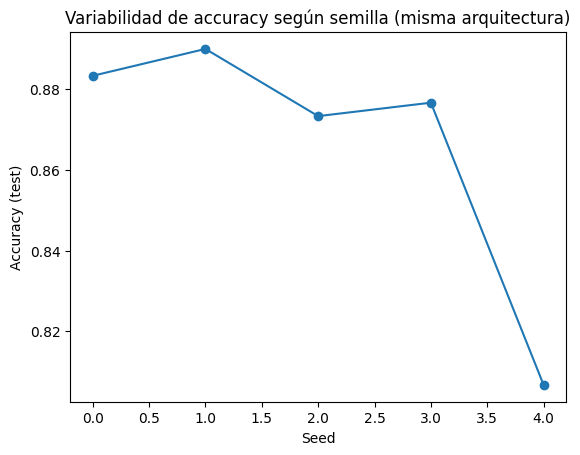

,seed,accuracy,precision,recall,f1,log_loss
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,0.866000,0.888050,0.834899,0.860434,0.341150
std,1.581139,0.033780,0.026005,0.049455,0.037778,0.054320
min,0.000000,0.806667,0.842105,0.751678,0.794326,0.297986
25%,1.000000,0.873333,0.894366,0.832215,0.867133,0.299355
50%,2.000000,0.876667,0.897260,0.852349,0.872852,0.335755
75%,3.000000,0.883333,0.901408,0.859060,0.879725,0.341153
max,4.000000,0.890000,0.905109,0.879195,0.888136,0.431504


In [15]:
plt.plot(stab["seed"], stab["accuracy"], marker="o")
plt.xlabel("Seed")
plt.ylabel("Accuracy (test)")
plt.title("Variabilidad de accuracy según semilla (misma arquitectura)")
plt.show()

stab.describe()


## Notebook · Bloque 9 — Reto: “Red minimalista” en un dataset con ruido

**Restricción:** red con **máximo 5 neuronas** en una capa oculta.  
**Objetivo:** rendimiento aceptable **y estable**, justificando decisiones.

Este dataset tiene más ruido para forzar el criterio (regularización, parada temprana, estabilidad y comparación con baseline).


In [16]:
# Dataset más ruidoso para el reto
Xr, yr = make_classification(
    n_samples=3000,
    n_features=25,
    n_informative=6,
    n_redundant=8,
    class_sep=0.8,
    flip_y=0.10,
    random_state=RANDOM_STATE
)

Xr_train, Xr_temp, yr_train, yr_temp = train_test_split(
    Xr, yr, test_size=0.30, random_state=RANDOM_STATE, stratify=yr
)
Xr_val, Xr_test, yr_val, yr_test = train_test_split(
    Xr_temp, yr_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=yr_temp
)

Xr_train.shape, Xr_val.shape, Xr_test.shape


((2100, 25), (450, 25), (450, 25))

In [17]:
def eval_classif_r(y_true, y_pred, y_proba=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        out["log_loss"] = log_loss(y_true, y_proba)
    return out

# Baselines del reto
dummy_r = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE).fit(Xr_train, yr_train)

logreg_r = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
]).fit(Xr_train, yr_train)

# Red minimalista (máximo 5 neuronas)
mlp_r = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(5,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        max_iter=900,
        random_state=RANDOM_STATE
    ))
]).fit(Xr_train, yr_train)

# Scoreboard del reto
pred_dummy_r = dummy_r.predict(Xr_test)
proba_dummy_r = dummy_r.predict_proba(Xr_test)

pred_lr_r = logreg_r.predict(Xr_test)
proba_lr_r = logreg_r.predict_proba(Xr_test)

pred_mlp_r = mlp_r.predict(Xr_test)
proba_mlp_r = mlp_r.predict_proba(Xr_test)

scoreboard_r = pd.DataFrame([
    {"modelo": "Dummy (most_frequent)", **eval_classif_r(yr_test, pred_dummy_r, proba_dummy_r)},
    {"modelo": "LogisticRegression", **eval_classif_r(yr_test, pred_lr_r, proba_lr_r)},
    {"modelo": "MLP (max 5 neuronas)", **eval_classif_r(yr_test, pred_mlp_r, proba_mlp_r)},
]).sort_values("accuracy", ascending=False)

scoreboard_r


,modelo,accuracy,precision,recall,f1,log_loss
1,LogisticRegression,0.822222,0.804255,0.847534,0.825328,0.455993
2,MLP (max 5 neuronas),0.815556,0.799145,0.838565,0.818381,0.457800
0,Dummy (most_frequent),0.504444,0.000000,0.000000,0.000000,17.861633


In [18]:
# Estabilidad del reto: misma red minimalista con distintas semillas
def train_eval_mlp_reto(seed, alpha=0.001):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(5,),
            activation="relu",
            solver="adam",
            alpha=alpha,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=10,
            max_iter=900,
            random_state=seed
        ))
    ])
    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)
    proba = model.predict_proba(Xr_test)
    return eval_classif_r(yr_test, pred, proba)

reto_seeds = list(range(10))
reto_stab = pd.DataFrame([{"seed": s, **train_eval_mlp_reto(s)} for s in reto_seeds])
reto_stab


,seed,accuracy,precision,recall,f1,log_loss
0,0,0.857778,0.832636,0.892377,0.861472,0.368922
1,1,0.788889,0.768908,0.820628,0.793926,0.457247
2,2,0.835556,0.828194,0.843049,0.835556,0.472616
3,3,0.804444,0.789700,0.825112,0.807018,0.473836
4,4,0.842222,0.819328,0.874439,0.845987,0.398603
5,5,0.766667,0.831461,0.663677,0.738155,0.462550
6,6,0.848889,0.860465,0.829596,0.844749,0.442157
7,7,0.831111,0.812766,0.856502,0.834061,0.431681
8,8,0.815556,0.812500,0.816143,0.814318,0.431051
9,9,0.837778,0.820513,0.860987,0.840263,0.422286


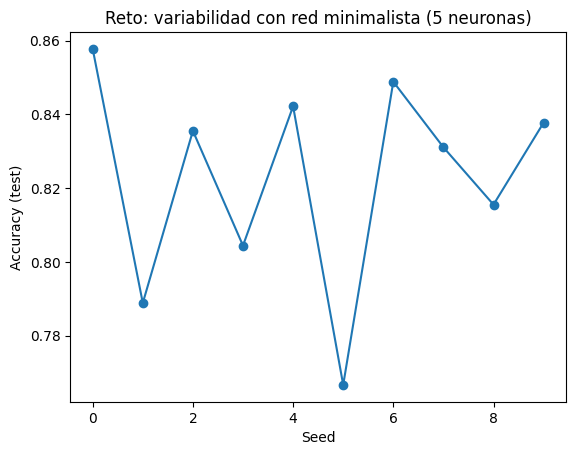

,seed,accuracy,precision,recall,f1,log_loss
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.50000,0.822889,0.817647,0.828251,0.821550,0.436095
std,3.02765,0.028728,0.024895,0.062924,0.035611,0.033492
min,0.00000,0.766667,0.768908,0.663677,0.738155,0.368922
25%,2.25000,0.807222,0.812566,0.821749,0.808843,0.424478
50%,4.50000,0.833333,0.819920,0.836323,0.834808,0.436919
75%,6.75000,0.841111,0.830644,0.859865,0.843627,0.461224
max,9.00000,0.857778,0.860465,0.892377,0.861472,0.473836


In [19]:
plt.plot(reto_stab["seed"], reto_stab["accuracy"], marker="o")
plt.xlabel("Seed")
plt.ylabel("Accuracy (test)")
plt.title("Reto: variabilidad con red minimalista (5 neuronas)")
plt.show()

reto_stab.describe()


## Cierre del notebook

Si has seguido el flujo completo, deberías poder responder con criterio a:

- ¿La red mejora **de forma clara** a los baselines?
- ¿La mejora es **estable** o depende del azar?
- ¿Dónde se ve el overfitting en las curvas?
- ¿Qué aporta `alpha` y qué aporta `early_stopping`?
- ¿Tus aciertos tienen margen (confianza) o estás “al filo” del 0.5?

> El objetivo de la sesión no es “saber entrenar una red”, sino **saber cuándo confiar en ella**.
